In [1]:
import pandas as pd

df = pd.read_csv('/content/archive (15).zip')
df = df[['text', 'airline_sentiment']]
df.head()


,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['airline_sentiment'])
X = df['text']

print(le.classes_)


['negative' 'neutral' 'positive']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)


In [5]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(X_train, maxlen=50)
X_test = pad_sequences(X_test, maxlen=50)

print(X_train.shape)
print(X_test.shape)


(11712, 50)
(2928, 50)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

n_classes = len(le.classes_)

model = Sequential([
    Embedding(5000, 32),
    SimpleRNN(32),
    Dense(n_classes, activation='softmax')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9859 - loss: 0.0563 - val_accuracy: 0.7371 - val_loss: 0.8799
Epoch 2/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9908 - loss: 0.0390 - val_accuracy: 0.7559 - val_loss: 0.9392
Epoch 3/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9923 - loss: 0.0305 - val_accuracy: 0.7576 - val_loss: 1.0302
Epoch 4/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9923 - loss: 0.0275 - val_accuracy: 0.7610 - val_loss: 1.0711
Epoch 5/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9934 - loss: 0.0232 - val_accuracy: 0.7516 - val_loss: 1.1109
Epoch 6/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9944 - loss: 0.0218 - val_accuracy: 0.7452 - val_loss: 1.1514
Epoch 7/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9941 - loss: 0.0192 - val_accuracy: 0.7371 - val_loss: 1.2494
Epoch 8/10
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.9934 - loss: 0.0219 - val_accu

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


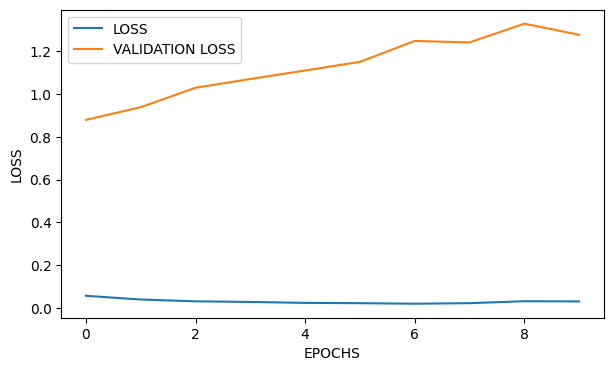

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], label='LOSS')
plt.plot(history.history['val_loss'], label='VALIDATION LOSS')
plt.xlabel('EPOCHS')
plt.ylabel('LOSS')
plt.legend()
plt.show()


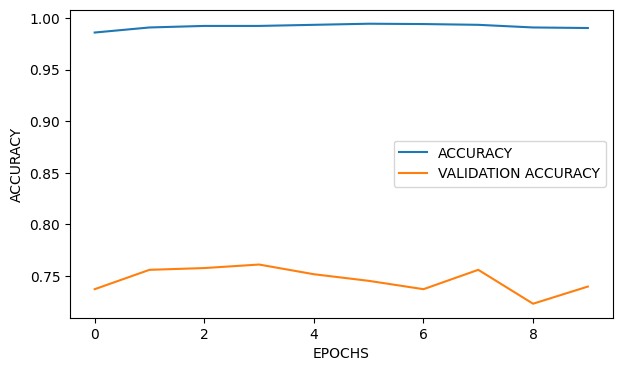

In [11]:
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='ACCURACY')
plt.plot(history.history['val_accuracy'], label='VALIDATION ACCURACY')
plt.xlabel('EPOCHS')
plt.ylabel('ACCURACY')
plt.legend()
plt.show()


### Vanishing Gradient Problem
In a plain RNN, gradients can become very small as they are passed backward through many time steps. This makes it difficult for the RNN to learn and remember information from much earlier parts of a long sequence.